In [1]:
import os
import glob
import gc

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import anndata as ad
import scanpy as sc

# pySCENIC imports

from dask.distributed import Client
from dask.diagnostics import ProgressBar

from arboreto.algo import grnboost2

from pyscenic.utils import modules_from_adjacencies, load_motifs
from pyscenic.prune import prune2df, df2regulons
from pyscenic.aucell import aucell
from pyscenic.rss import regulon_specificity_scores

import networkx as nx
import community as community_louvain
from collections import defaultdict

from ctxcore.rnkdb import FeatherRankingDatabase as RankingDatabase

%matplotlib inline

/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/deepak/pixi_envs/scenic/.pixi/envs/default/l

In [2]:
# DEFINE PATHS ##

SCENIC_PATH = '/mnt/sdb/scz_meta_analysis_processed/scenic_files/'
FEATHER_RANKINGS_FILE = 'hg38_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather'
DATABASES_GLOB = os.path.join(SCENIC_PATH, FEATHER_RANKINGS_FILE)
MOTIF_ANNOTATIONS_FNAME = os.path.join(SCENIC_PATH, 'motifs-v10nr_clust-nr.hgnc-m0.001-o0.0.tbl')

In [4]:
## SAVE LOAD ##

# Organoids #
ORGANOIDS_PATH = '/mnt/sdb/scz_meta_analysis_processed/anndata_objs'
organoids_filename = 'integrated_adata_annotated_w_celltypist_scanvi.h5ad'
scz_adata = sc.read_h5ad(os.path.join(ORGANOIDS_PATH, organoids_filename))

# TF List ##
TF_LIST = "/home/deepak/datasets/developing_hippocampus/roussos_organoid_snrnaseq/scenic_files/allTFs_hg38.txt"
tf_list = pd.read_csv(TF_LIST, header=None)[0].tolist()

In [5]:
# Work With Raw Counts #

scz_adata.X = scz_adata.layers['raw_counts']

genotype_order = ['Control', 'Idiopathic_Schizophrenia', '3q29del', '15q13.3del', '22q11.2del', 'NRXN1del']

celltype_order = ['Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+',
                   'Radial Glia SOX2+VIM+FABP7+', 'Proliferative Radial Glia SOX2+HES6+TOP2A+',
                   'Hindbrain Neurons NR2F2+PBX3+LHX1+',  'Radial Glia SOX2+PAX6+FABP7+', 
                  'Mesenchymal-like cells VIM+VCAN+SPARC+', 'Mixed Neurons FGF12+GRIN2B+CAMK2B+', 
                  'GABAergic GAD1+GAD2+CALB2+', 'Stressed Glia FTL+B2M+GLUL+']

scz_adata.obs['Genotype_Celltype'] = (scz_adata.obs['Broad_Genotype'].astype('str') + '_' +
                                      scz_adata.obs['subclass_annotations_markers'].astype('str'))

split = scz_adata.obs['Genotype_Celltype'].str.split('_', n=1, expand=True)
scz_adata.obs['Genotype'] = pd.Categorical(split[0], genotype_order, True)
scz_adata.obs['CellType'] = pd.Categorical(split[1], celltype_order, True)
scz_adata.obs['Donor_Sample'] = scz_adata.obs['Donor'].astype('str') + '_' + scz_adata.obs['Sample Name'].astype('str') 

In [20]:
## Filter Adata ##

# filter on HVGs but spare TFs #
sc.pp.highly_variable_genes(scz_adata, layer='log1p_norm', n_top_genes=10000, subset=False, inplace=True, batch_key='Manuscript')

min_cells = max(10, int(0.01 * scz_adata.n_obs))
expressed_TFs = scz_adata.var_names[scz_adata.var_names.isin(tf_list) & 
                ((scz_adata.X > 0).sum(axis=0).A1 >= min_cells)]

# Union of HVGs and expressed TFs
gene_filter = scz_adata.var['highly_variable_features'] | scz_adata.var_names.isin(expressed_TFs)
scz_adata = scz_adata[:, gene_filter].copy()

# Convert to genes x cells DataFrame (pySCENIC expects this shape)
counts_matrix_not_pb = pd.DataFrame(
    scz_adata.X.T.toarray() if not isinstance(scz_adata.X, np.ndarray) else scz_adata.X.T,
    index=scz_adata.var['hgnc_symbol'],
    columns=scz_adata.obs_names)

counts_matrix = counts_matrix_not_pb.groupby(scz_adata.obs['Donor_Sample'], axis=1).agg(np.nanmean)

/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default o

In [11]:
counts_matrix.index.isin(tf_list).sum()

1453

In [12]:
## RUN GRNBOOST2

# 1) Make sure your expression is cells × genes
expr = counts_matrix.T  # cells x genes
# ensure columns are strings
expr.columns = expr.columns.astype(str)

# 2) Start a local in-process client (no separate worker processes)
client = Client(
    n_workers=1,
    threads_per_worker=24,   # or 24/32 if you have lots of cores
    processes=False,         # <<< critical: use threads, not processes
    dashboard_address=None)

print(client)  # sanity check

# 3) Run GRNBoost2 with the local threaded client
adjacencies = grnboost2(
    expression_data=expr,
    gene_names=expr.columns,   # make the mapping explicit
    tf_names=list(expr.columns[expr.columns.isin(tf_list)]),
    client_or_address=client,
    verbose=True)

<Client: 'inproc://192.168.4.23/134569/1' processes=1 threads=24, memory=503.56 GiB>
preparing dask client
parsing input
creating dask graph
1 partitions
computing dask graph
not shutting down client, client was created externally
finished


2026-04-18 11:27:36,274 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 352.51 GiB -- Worker memory limit: 503.56 GiB


In [13]:
len(tf_list)

1892

In [14]:
adjacencies.to_csv("/mnt/sdb/scz_meta_analysis_processed/scenic_files/grnboost2_adjacencies.tsv", index=False)

In [26]:
DATABASES_GLOB

'/mnt/sdb/scz_meta_analysis_processed/scenic_files/hg38_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather'

In [27]:
## STEP 2-3: Regulon prediction aka cisTarget from CLI ##

# Build Modules #

modules = list(modules_from_adjacencies(adjacencies, expr))

## Makes Rankings File Into FeatherRankignsDatabase Object ##

db_fnames = glob.glob(DATABASES_GLOB)

def name(fname):
    return os.path.splitext(os.path.basename(fname))[0]
    
dbs = [RankingDatabase(fname=fname, name=name(fname)) for fname in db_fnames]

## Calculate a list of enriched motifs and the corresponding target genes for all modules ##

with ProgressBar():
    df = prune2df(dbs, modules, MOTIF_ANNOTATIONS_FNAME)

## Create regulons from this table of enriched motifs.

regulons = df2regulons(df)


2026-04-18 11:21:34,244 - pyscenic.utils - INFO - Calculating Pearson correlations.

2026-04-18 11:21:34,307 - pyscenic.utils - WARNING - Note on correlation calculation: the default behaviour for calculating the correlations has changed after pySCENIC verion 0.9.16. Previously, the default was to calculate the correlation between a TF and target gene using only cells with non-zero expression values (mask_dropouts=True). The current default is now to use all cells to match the behavior of the R verision of SCENIC. The original settings can be retained by setting 'rho_mask_dropouts=True' in the modules_from_adjacencies function, or '--mask_dropouts' from the CLI.
	Dropout masking is currently set to [False].

2026-04-18 11:21:36,262 - pyscenic.utils - INFO - Creating modules.


[                                        ] | 0% Completed | 129.81 ms

/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/dask/base.py:1368: UserWarning: Running on a single-machine scheduler when a distributed client is active might lead to unexpected results.
  warnings.warn(


[                                        ] | 0% Completed | 5.83 s ms

/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/ctxcore/__init__.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


...

[################                        ] | 40% Completed | 83.65 s


2026-04-18 11:23:09,602 - pyscenic.transform - WARNING - Less than 80% of the genes in Regulon for LEF1 could be mapped to hg38_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings. Skipping this module.


[####################################    ] | 91% Completed | 91.61 s


2026-04-18 11:23:17,525 - pyscenic.transform - WARNING - Less than 80% of the genes in PARP1 could be mapped to hg38_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings. Skipping this module.


[########################################] | 100% Completed | 93.22 s
Create regulons from a dataframe of enriched features.
Additional columns saved: []


In [28]:
## Visualize Regulons ##

auc_mtx = aucell(counts_matrix_not_pb.T, regulons, num_workers=8)

# ensure alignment
auc_mtx = auc_mtx.loc[scz_adata.obs_names]

# calculate rss specificity score
rss = regulon_specificity_scores(auc_mtx, scz_adata.obs['Genotype_Celltype'])

In [591]:
## Make Disease Specific AUC MTXs ##
rss_22q11 = auc_mtx.copy()
rss_nrxn1 = auc_mtx.copy()
rss_idiopathic = auc_mtx.copy()

## 22q11 ##
rss_22q11['Broad_Genotype'] = scz_adata.obs['Broad_Genotype']
rss_22q11['Manuscript'] = scz_adata.obs['Manuscript']
rss_22q11 = rss_22q11[(rss_22q11['Manuscript'].str.contains('Rao|Shin|Walsh') & ~(rss_22q11['Broad_Genotype'].str.contains('15q13')))]
del rss_22q11['Manuscript']
del rss_22q11['Broad_Genotype']

## NRXN1 ##
rss_nrxn1['Manuscript'] = scz_adata.obs['Manuscript']
rss_nrxn1 = rss_nrxn1[rss_nrxn1['Manuscript'].str.contains('Fernando|Sebastian')]
del rss_nrxn1['Manuscript']

## Idiopathic ##
rss_idiopathic['Manuscript'] = scz_adata.obs['Manuscript']
rss_idiopathic = rss_idiopathic[rss_idiopathic['Manuscript'].str.contains('Notaras|Sawada')]
del rss_idiopathic['Manuscript']

## AUC MTX ##
auc_mtx_idiopathic = auc_mtx.loc[rss_idiopathic.index]
auc_mtx_22q11 = auc_mtx.loc[rss_22q11.index]
auc_mtx_nrxn1 = auc_mtx.loc[rss_nrxn1.index]

/tmp/ipykernel_134569/326546180.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.clustermap(auc_mtx.groupby(scz_adata.obs['subclass_annotations_markers']).mean())


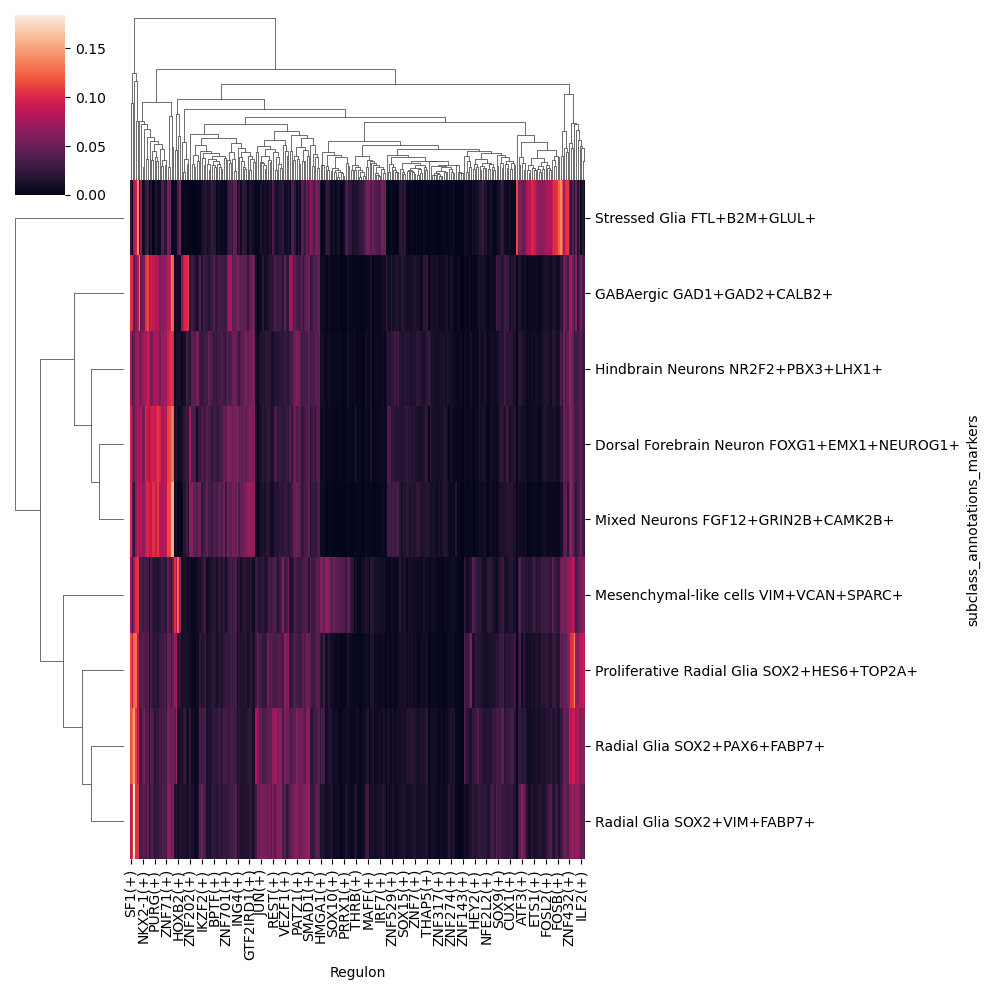

In [29]:
sns.clustermap(auc_mtx.groupby(scz_adata.obs['subclass_annotations_markers']).mean())

/tmp/ipykernel_134569/697381507.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.clustermap(auc_mtx.groupby(scz_adata.obs['subtype_cluster_annotations']).mean())
/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


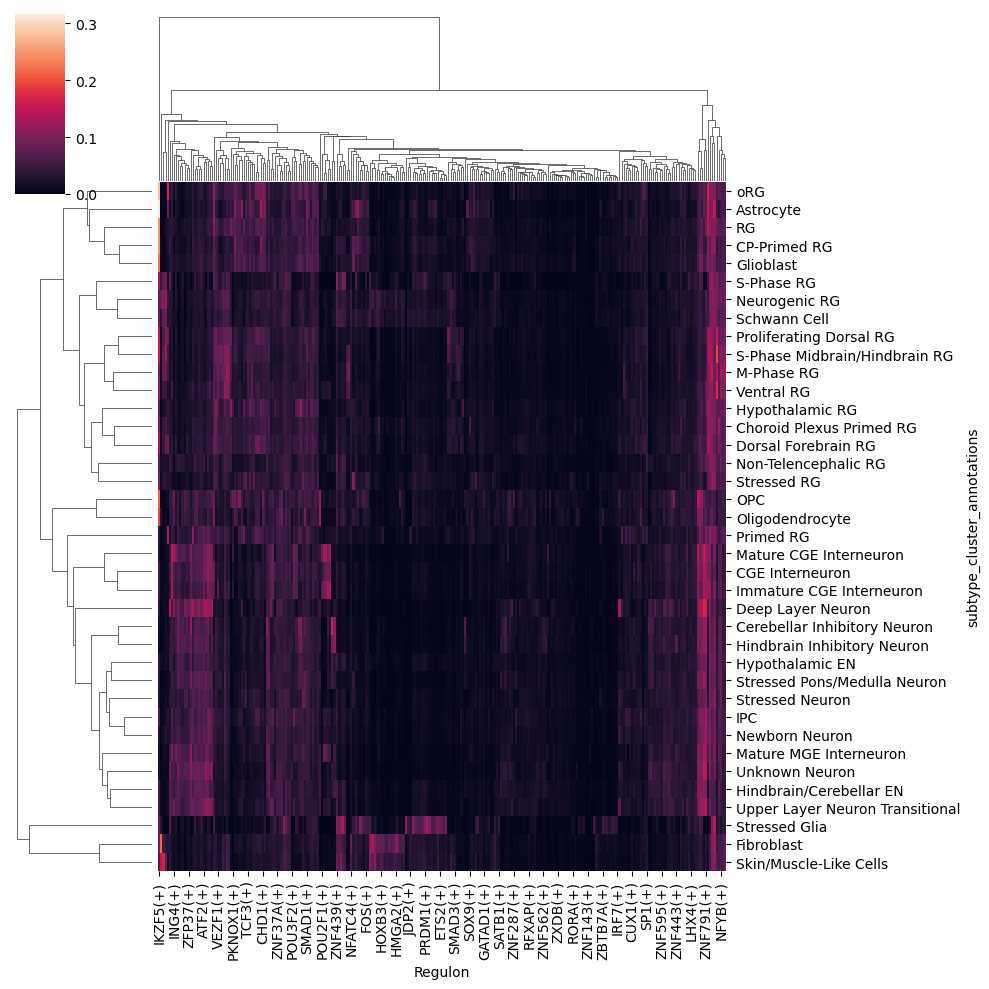

In [33]:
sns.clustermap(auc_mtx.groupby(scz_adata.obs['subtype_cluster_annotations']).mean())

Text(0, 0.5, 'Number of regulons')

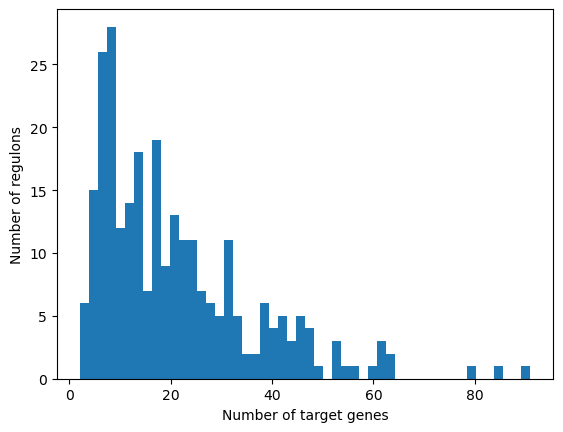

In [34]:
regulon_sizes = [len(r.genes) for r in regulons]
plt.hist(regulon_sizes, bins=50)
plt.xlabel("Number of target genes")
plt.ylabel("Number of regulons")

In [35]:
list([len(r.genes) for r in regulons])

[4,
 40,
 25,
 8,
 10,
 23,
 45,
 53,
 44,
 16,
 57,
 84,
 47,
 35,
 11,
 32,
 9,
 38,
 14,
 18,
 25,
 24,
 17,
 9,
 36,
 52,
 9,
 20,
 8,
 3,
 47,
 46,
 17,
 34,
 62,
 14,
 15,
 17,
 28,
 18,
 46,
 42,
 17,
 19,
 11,
 43,
 27,
 20,
 80,
 53,
 24,
 7,
 19,
 6,
 6,
 43,
 28,
 11,
 54,
 14,
 46,
 63,
 32,
 26,
 7,
 14,
 7,
 9,
 31,
 10,
 10,
 14,
 10,
 13,
 38,
 28,
 7,
 38,
 7,
 28,
 22,
 4,
 6,
 24,
 20,
 61,
 22,
 23,
 17,
 24,
 11,
 60,
 14,
 9,
 14,
 20,
 12,
 38,
 31,
 11,
 24,
 5,
 22,
 31,
 9,
 22,
 11,
 21,
 3,
 12,
 29,
 42,
 18,
 48,
 5,
 91,
 8,
 40,
 32,
 36,
 5,
 20,
 19,
 26,
 21,
 31,
 46,
 10,
 15,
 9,
 19,
 10,
 7,
 4,
 11,
 11,
 29,
 18,
 42,
 18,
 35,
 9,
 20,
 26,
 19,
 16,
 5,
 40,
 23,
 8,
 6,
 14,
 26,
 34,
 6,
 9,
 18,
 31,
 17,
 13,
 29,
 5,
 12,
 40,
 5,
 20,
 10,
 16,
 7,
 26,
 18,
 8,
 42,
 11,
 19,
 20,
 8,
 61,
 31,
 24,
 6,
 10,
 29,
 13,
 24,
 33,
 29,
 13,
 26,
 24,
 42,
 3,
 50,
 18,
 9,
 14,
 10,
 27,
 20,
 20,
 8,
 10,
 64,
 23,
 17,
 10,
 6,
 14,
 8,

In [36]:
for r in regulons:
    print(r.name, len(r.genes), r.transcription_factor, r.context)

AR(+) 4 AR frozenset({'activating', 'cisbp__M00821.png'})
ARID3A(+) 40 ARID3A frozenset({'tfdimers__MD00032.png', 'activating'})
ATF2(+) 25 ATF2 frozenset({'activating', 'tfdimers__MD00437.png'})
ATF3(+) 8 ATF3 frozenset({'activating', 'metacluster_111.4.png'})
ATF4(+) 10 ATF4 frozenset({'activating', 'taipale_tf_pairs__ATF4_TEF_RNMTGATGCAATN_CAP.png'})
BACH1(+) 23 BACH1 frozenset({'activating', 'tfdimers__MD00098.png'})
BACH2(+) 45 BACH2 frozenset({'tfdimers__MD00332.png', 'activating'})
BCL11A(+) 53 BCL11A frozenset({'activating', 'metacluster_167.2.png'})
BHLHE41(+) 44 BHLHE41 frozenset({'tfdimers__MD00046.png', 'activating'})
BPTF(+) 16 BPTF frozenset({'activating', 'tfdimers__MD00229.png'})
CEBPA(+) 57 CEBPA frozenset({'activating', 'tfdimers__MD00535.png'})
CEBPB(+) 84 CEBPB frozenset({'tfdimers__MD00394.png', 'activating'})
CEBPD(+) 47 CEBPD frozenset({'tfdimers__MD00110.png', 'activating'})
CEBPG(+) 35 CEBPG frozenset({'tfdimers__MD00263.png', 'activating'})
CENPB(+) 11 CENPB f

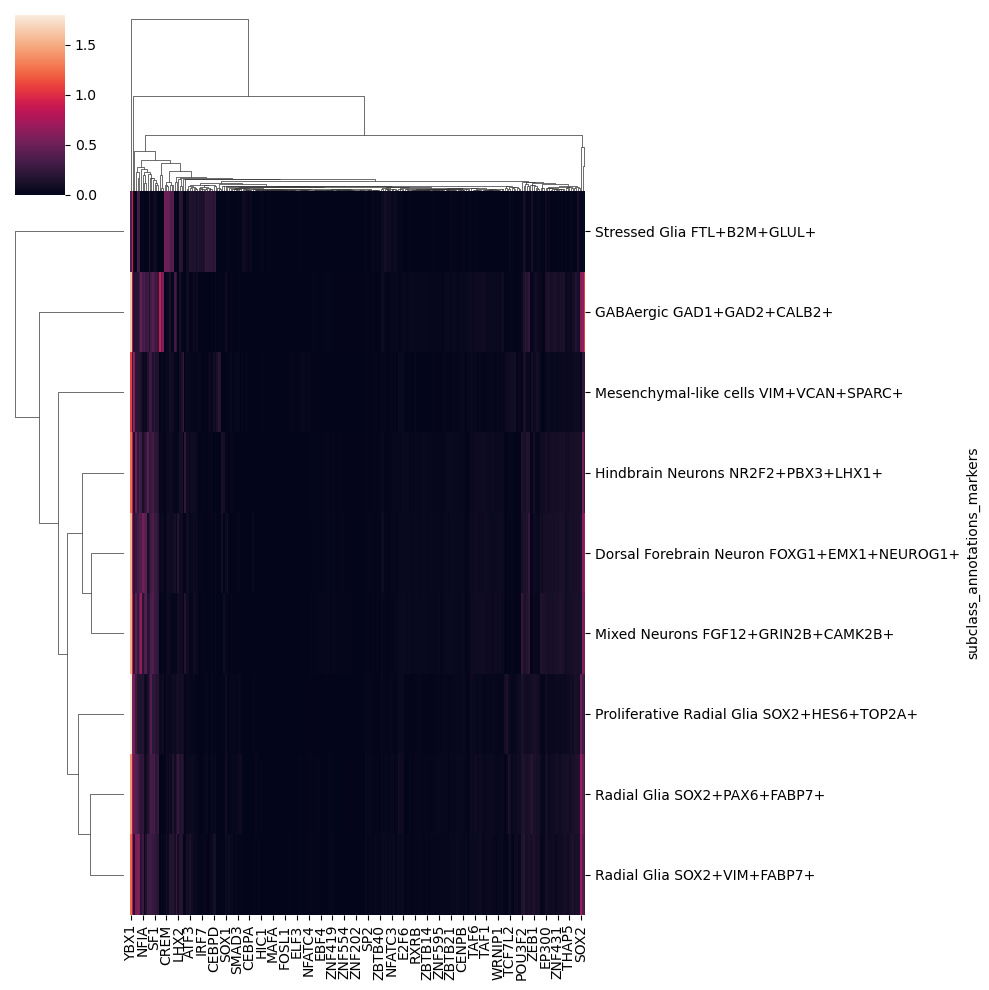

In [40]:
## Isolate TFs for Each Regulon#

TFs = [i.strip('(+)') for i in auc_mtx.columns]

# Make DF where TFs are on the X and all cells arranged by subtype on the Y

TF_df = pd.DataFrame(data=scz_adata[scz_adata.obs.sort_values('subclass_annotations_markers').index,TFs].layers['log1p_norm'].toarray(),
                     index=scz_adata.obs.sort_values('subclass_annotations_markers').index,
                     columns=TFs)

TF_df = TF_df.reset_index(drop=True)
TF_df.columns = [str(col) for col in TF_df.columns]

# Make DF where TFs are on the X and aggregated subtypes are on the Y

TF_subtype_df = pd.DataFrame(
    scz_adata[:, TFs].layers['log1p_norm'].toarray(),  # convert sparse matrix to dense
    columns=TFs,
    index=scz_adata.obs['subclass_annotations_markers'])

TF_subtype_df = TF_subtype_df.groupby(level=0).mean()

## Visualize #

# top 10% variance
sns.clustermap(TF_subtype_df.loc[:, TF_subtype_df.var(axis=0) >= TF_subtype_df.var(axis=0).quantile(0.9)])

In [202]:
## Trying to make a Cell Type Specific Regulon Heatmap ##

# Ensure alignment
auc_mtx = auc_mtx.loc[scz_adata.obs_names]

# Compute RSS (regulons x cell types)
rss = regulon_specificity_scores(auc_mtx, scz_adata.obs['subclass_annotations_markers'])

In [283]:
top_n = 4

# Convert to long format
rss_long = rss.reset_index().melt(id_vars='index', var_name='regulon', value_name='rss').rename(columns={'index': 'cell_type'})

# Get top N regulons per cell type
top_regulons_df = (rss_long.sort_values(['cell_type', 'rss'], ascending=[True, False]).groupby('cell_type').head(top_n))

top_regulons_df = top_regulons_df[~top_regulons_df['regulon'].duplicated()]

In [284]:
# Add cell type labels
auc_with_ct = auc_mtx.copy()
auc_with_ct['cell_type'] = scz_adata.obs['subclass_annotations_markers'].values

# Mean AUC per cell type
mean_auc = auc_with_ct.groupby('cell_type').mean()

/tmp/ipykernel_134569/346727537.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_auc = auc_with_ct.groupby('cell_type').mean()


In [285]:
mean_auc['celltype'] = mean_auc.index

mean_auc_melted = pd.melt(mean_auc[top_regulons_df['regulon'].tolist() + ['celltype']], id_vars=['celltype'], value_name='AUC')

In [286]:
# -----------------------------
# 1. Choose regulons (same as heatmap)
# -----------------------------
regulons = mean_auc[top_regulons_df['regulon'].tolist()].columns.tolist()
celltypes = mean_auc.index.tolist()

auc_mat = mean_auc.loc[celltypes, regulons]
rss_mat = rss.loc[celltypes, regulons]

# -----------------------------
# 2. Build coordinate maps
# -----------------------------
x_map = {r: i for i, r in enumerate(regulons)}
y_map = {c: i for i, c in enumerate(celltypes)}

# -----------------------------
# 3. Convert RSS to long format
# -----------------------------
rss_long = (rss_mat.reset_index().rename(columns={'index': 'celltype'}).melt(id_vars='celltype',
                                                                             var_name='regulon',
                                                                             value_name='rss_score'))
# -----------------------------
# 4. Align to heatmap grid ONLY
# -----------------------------
rss_long = rss_long[rss_long['celltype'].isin(celltypes) & rss_long['regulon'].isin(regulons)].copy()

# -----------------------------
# 5. Map to heatmap coordinates
# -----------------------------
rss_long['x'] = rss_long['regulon'].map(x_map)
rss_long['y'] = rss_long['celltype'].map(y_map)

# -----------------------------
# 6. Final safety checks
# -----------------------------
assert rss_long['x'].notnull().all()
assert rss_long['y'].notnull().all()
assert len(rss_long) == len(celltypes) * len(regulons)

In [290]:
baseline = rss_long['rss_score'].min()

rss_scaled = (rss_long['rss_score'] - baseline)
rss_scaled = np.clip(rss_scaled, 0, None)

rss_scaled = rss_scaled / rss_scaled.max()
rss_scaled = np.sqrt(rss_scaled)

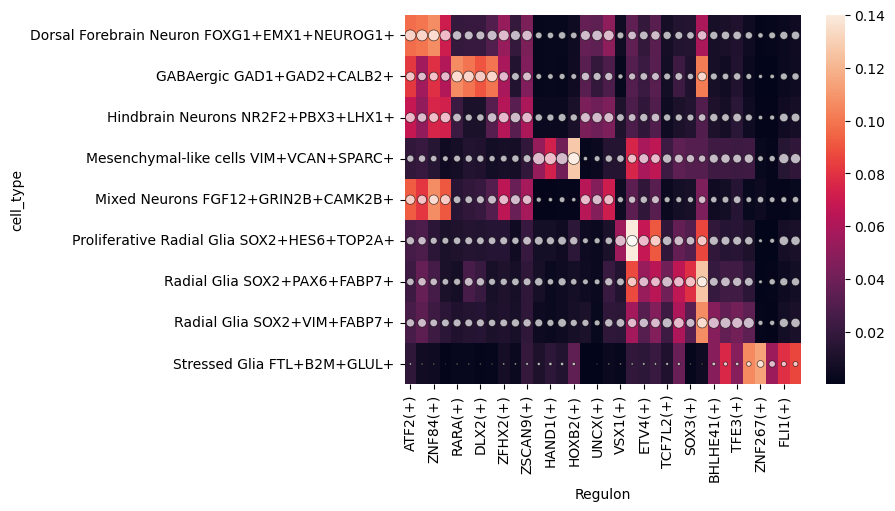

In [291]:
fig, ax = plt.subplots()

sns.heatmap(mean_auc[top_regulons_df['regulon'].tolist()], ax=ax)

ax = plt.gca()

ax.scatter(
    rss_long['x'] + 0.5,
    rss_long['y'] + 0.5,
    s=rss_scaled * 75,
    c='white',
    edgecolor='black',
    linewidth=0.5,
    alpha=0.7,
    zorder=10)

plt.show()

In [554]:
## Trying to make a Disease Specific Regulon Heatmap ##

top_n = 3


scz_adata.obs = scz_adata.obs.sort_values(['Genotype', 'CellType'])

# Convert to long format
rss_22q11['Genotype_Celltype'] = scz_adata.obs['Genotype_Celltype']
rss_22q11['Genotype'] = scz_adata.obs['Broad_Genotype']
rss_22q11['CellType'] = scz_adata.obs['subclass_annotations_markers']

rss_long = rss_22q11.reset_index(drop=True).melt(id_vars=['Genotype_Celltype','CellType', 'Genotype'], 
                                                 var_name='regulon', value_name='rss')

# assign genotype by matching prefix (safe for underscores)
rss_long['Genotype'] = pd.NA
for g in genotype_order:
    mask = rss_long['Genotype_Celltype'].str.startswith(g + "_")
    rss_long.loc[mask, 'Genotype'] = g

# enforce ordering
rss_long['Genotype'] = pd.Categorical(rss_long['Genotype'], genotype_order, True)
rss_long['CellType'] = pd.Categorical(rss_long['CellType'], celltype_order, True)

rss_long = rss_long.sort_values(['Genotype', 'CellType'])

# Get top N regulons per cell type
top_regulons_df = (rss_long.sort_values(['Genotype_Celltype', 
                                         'rss'], ascending=[True, False]).groupby('Genotype_Celltype').head(top_n))

top_regulons_df = top_regulons_df[~top_regulons_df['regulon'].duplicated()]

# Add cell type labels
# auc_with_ct = auc_mtx.copy()
auc_with_ct = auc_mtx_22q11.copy()
auc_with_ct['Genotype_Celltype'] = scz_adata.obs['Genotype_Celltype']

# Mean AUC per cell type
mean_auc = auc_with_ct.groupby('Genotype_Celltype').mean()

mean_auc['Genotype_Celltype'] = mean_auc.index

mean_auc['Broad_Genotype'] = mean_auc['Genotype_Celltype'].str.split('_').apply(lambda x: x[0])
mean_auc['Broad_Genotype'] = pd.Categorical(mean_auc['Broad_Genotype'], ordered=True, categories=genotype_order)

mean_auc['CellType'] = mean_auc['Genotype_Celltype'].str.split('_').apply(lambda x: x[1])
mean_auc['CellType'] = pd.Categorical(mean_auc['CellType'], ordered=True, categories=celltype_order)

mean_auc = mean_auc.sort_values(by=['Broad_Genotype', 'CellType'])

In [555]:
# (rss_long.sort_values(['Genotype_Celltype', 'rss'], ascending=[True, False, False]) #.groupby('Genotype_Celltype').head(top_n))

In [556]:
# -----------------------------
# 1. Choose regulons (same as heatmap)
# -----------------------------
regulons = mean_auc[top_regulons_df['regulon'].tolist()].columns.tolist()
celltypes = mean_auc.index.tolist()

auc_mat = mean_auc.loc[celltypes, regulons]
rss_mat = rss.loc[celltypes, regulons]

# -----------------------------
# 2. Build coordinate maps
# -----------------------------
x_map = {r: i for i, r in enumerate(regulons)}
y_map = {c: i for i, c in enumerate(celltypes)}

# -----------------------------
# 3. Convert RSS to long format
# -----------------------------
rss_long = (rss_mat.reset_index().rename(columns={'index': 'Genotype_Celltype'}).melt(id_vars='Genotype_Celltype',
                                                                             var_name='regulon',
                                                                             value_name='rss_score'))
# -----------------------------
# 4. Align to heatmap grid ONLY
# -----------------------------
rss_long = rss_long[rss_long['Genotype_Celltype'].isin(celltypes) & rss_long['regulon'].isin(regulons)].copy()

# -----------------------------
# 5. Map to heatmap coordinates
# -----------------------------
rss_long['x'] = rss_long['regulon'].map(x_map)
rss_long['y'] = rss_long['Genotype_Celltype'].map(y_map)

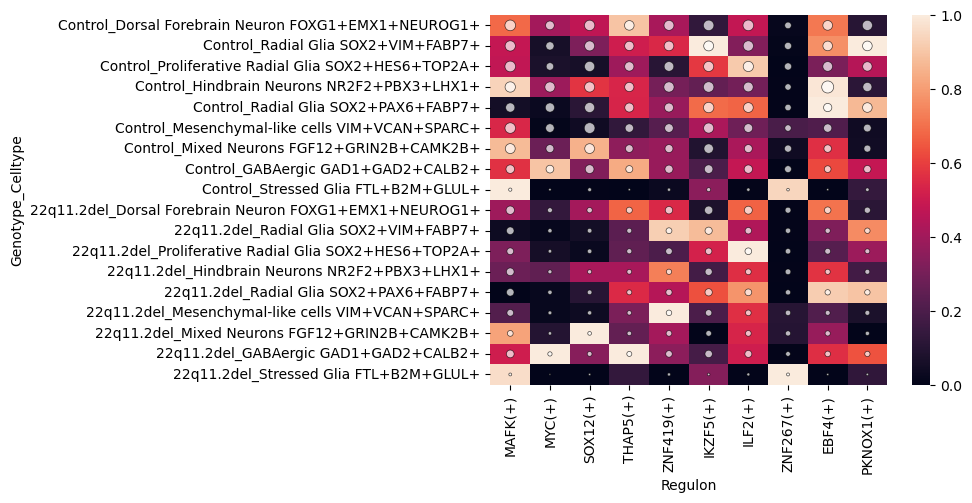

In [561]:
baseline = rss_long['rss_score'].min()

rss_scaled = (rss_long['rss_score'] - baseline)
rss_scaled = np.clip(rss_scaled, 0, None)

rss_scaled = rss_scaled / rss_scaled.max()
rss_scaled = np.sqrt(rss_scaled)

fig, ax = plt.subplots()

mean_auc_plot = mean_auc[top_regulons_df['regulon'].tolist()]

mean_auc_plot = (mean_auc_plot - mean_auc_plot.min()) / (mean_auc_plot.max() - mean_auc_plot.min())

sns.heatmap(mean_auc_plot, ax=ax)

ax = plt.gca()

ax.scatter(
    rss_long['x'] + 0.5,
    rss_long['y'] + 0.5,
    s=rss_scaled * 75,
    c='white',
    edgecolor='black',
    linewidth=0.5,
    alpha=0.7,
    zorder=10)

plt.show()